# California Housing: Regression Models

Target: **median_house_value** (continuous).

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

TARGET_COL = "median_house_value" 

## Load Dataset

In [2]:
df = pd.read_csv(r"D:\NTI\regression_project\data\housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Data Quality Check

In [5]:
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Duplicate rows: 0


`total_bedrooms` has some missing values, we fill them with the median.

In [6]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

## EDA

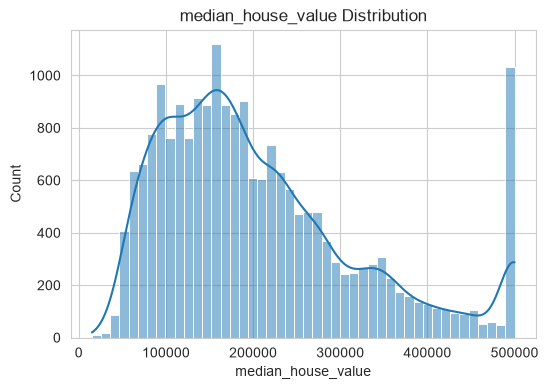

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], kde=True)
plt.title(f"{TARGET_COL} Distribution")
plt.show()

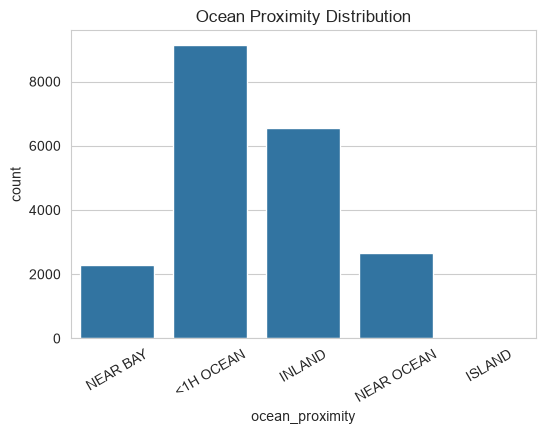

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="ocean_proximity", data=df)
plt.title("Ocean Proximity Distribution")
plt.xticks(rotation=30)
plt.show()

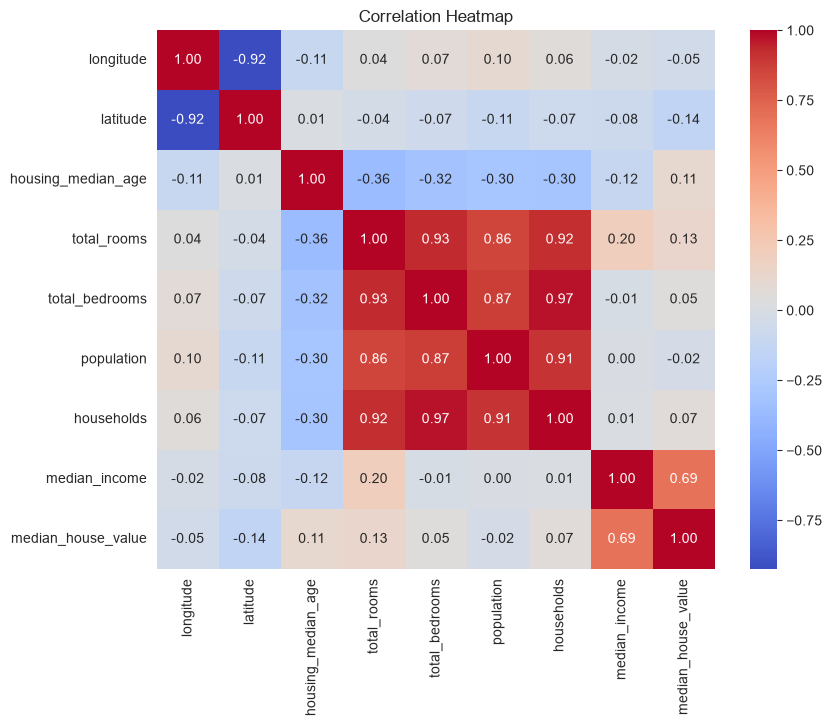

In [9]:
numeric_df = df.drop("ocean_proximity", axis=1)

plt.figure(figsize=(9,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Feature Encoding

`ocean_proximity` is categorical, we one-hot encode it.

In [10]:
df_encoded = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## Feature Selection & Train-Test Split

In [11]:
X = df_encoded.drop(TARGET_COL, axis=1)
y = df_encoded[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (16512, 12), Test shape: (4128, 12)


## Feature Scaling

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model 1: Linear Regression

In [13]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"MAE:  {mae_lin:.4f}")
print(f"MSE:  {mse_lin:.4f}")
print(f"RMSE: {rmse_lin:.4f}")
print(f"R2:   {r2_lin:.4f}")

MAE:  50670.7382
MSE:  4908476721.1566
RMSE: 70060.5218
R2:   0.6254


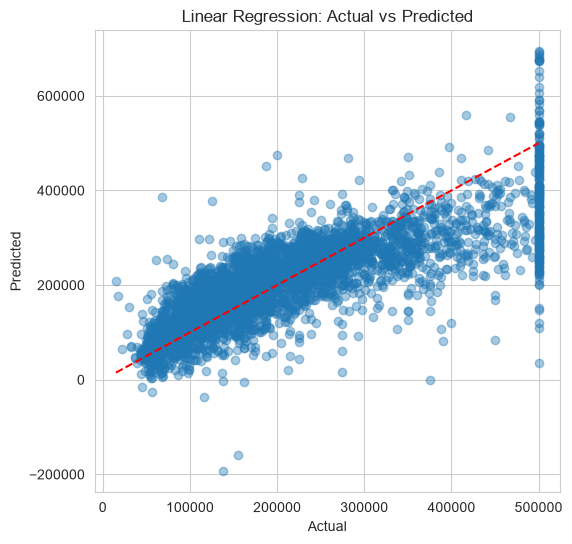

In [14]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

## Model 2: Decision Tree Regressor

In [15]:
dt_reg = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_reg.fit(X_train_scaled, y_train)

y_pred_dt = dt_reg.predict(X_test_scaled)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"MAE:  {mae_dt:.4f}")
print(f"MSE:  {mse_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R2:   {r2_dt:.4f}")

MAE:  44120.6800
MSE:  4855424720.3408
RMSE: 69680.8777
R2:   0.6295


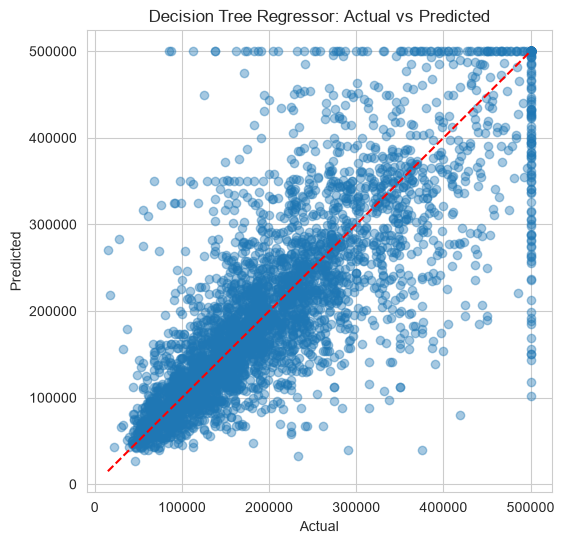

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree Regressor: Actual vs Predicted")
plt.show()

## Model 3: Random Forest Regressor

In [17]:
rf_reg = RandomForestRegressor(random_state=RANDOM_STATE)
rf_reg.fit(X_train_scaled, y_train)

y_pred_rf = rf_reg.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE:  {mae_rf:.4f}")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")

MAE:  31631.0187
MSE:  2401861420.4517
RMSE: 49008.7892
R2:   0.8167


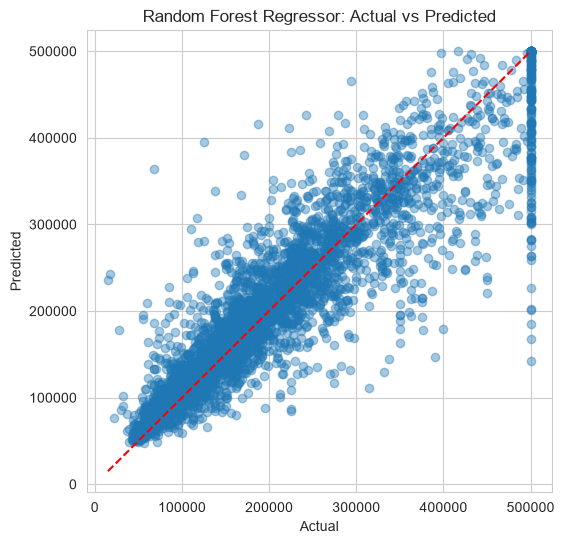

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Regressor: Actual vs Predicted")
plt.show()

## Model 4: XGBoost Regressor

In [19]:
xgb_reg = XGBRegressor(random_state=RANDOM_STATE)
xgb_reg.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_reg.predict(X_test_scaled)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MAE:  {mae_xgb:.4f}")
print(f"MSE:  {mse_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2:   {r2_xgb:.4f}")

MAE:  31887.3921
MSE:  2329632845.2618
RMSE: 48266.2703
R2:   0.8222


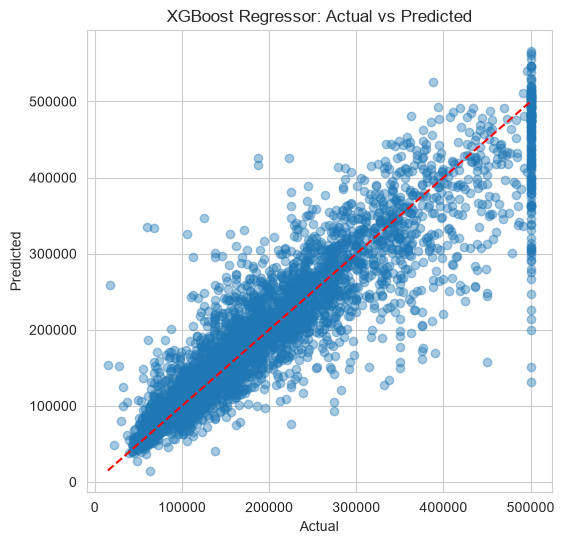

In [20]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost Regressor: Actual vs Predicted")
plt.show()

## Feature Importance

C:\Users\PC\AppData\Local\Temp\ipykernel_20004\4153200293.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_rf.values, y=importances_rf.index, palette=colors)


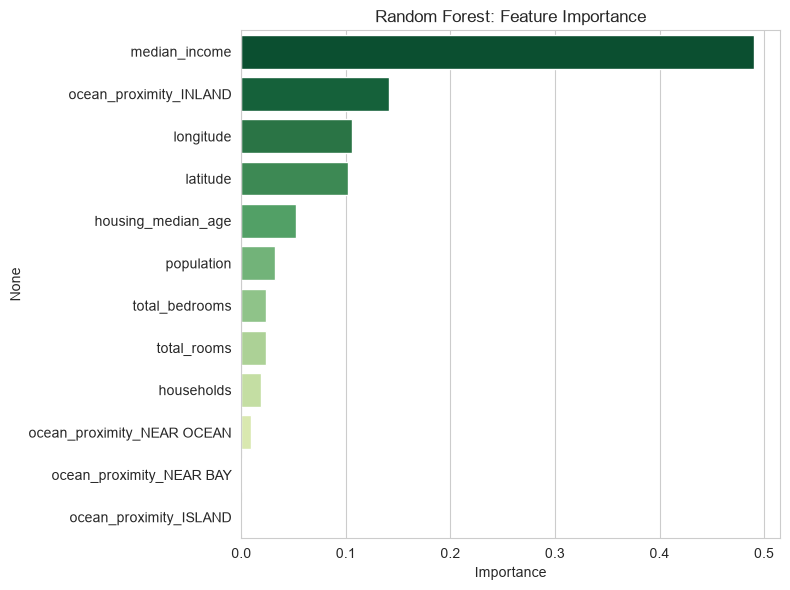

Most influential feature (RF): median_income


In [21]:
importances_rf = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
colors = sns.color_palette("YlGn", len(importances_rf))[::-1]
sns.barplot(x=importances_rf.values, y=importances_rf.index, palette=colors)
plt.title("Random Forest: Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(f"Most influential feature (RF): {importances_rf.index[0]}")


C:\Users\PC\AppData\Local\Temp\ipykernel_20004\2178935316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_xgb.values, y=importances_xgb.index, palette=colors)


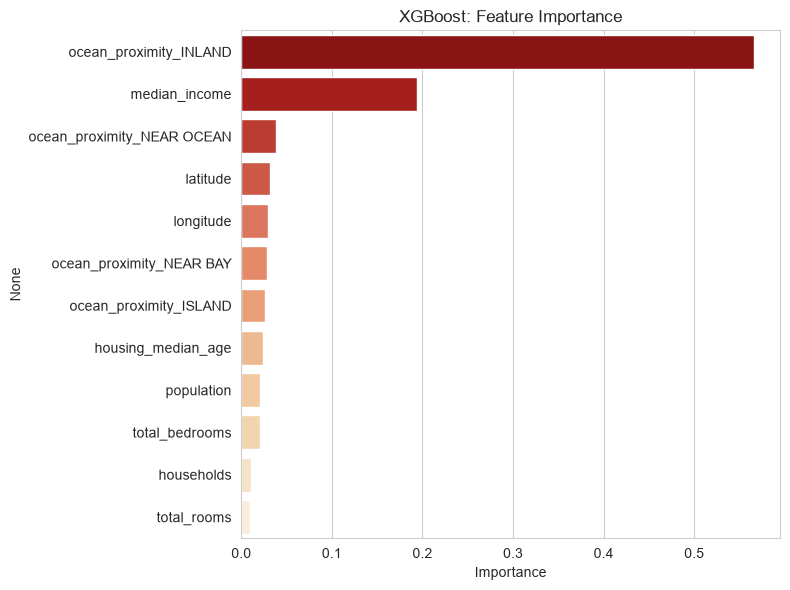

Most influential feature (XGBoost): ocean_proximity_INLAND


In [22]:
importances_xgb = pd.Series(xgb_reg.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
colors = sns.color_palette("OrRd", len(importances_xgb))[::-1]
sns.barplot(x=importances_xgb.values, y=importances_xgb.index, palette=colors)
plt.title("XGBoost: Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(f"Most influential feature (XGBoost): {importances_xgb.index[0]}")


## Compare Models

In [23]:
comparison = pd.DataFrame([
    {"Model": "Linear Regression", "MAE": mae_lin, "MSE": mse_lin, "RMSE": rmse_lin, "R2": r2_lin},
    {"Model": "Decision Tree", "MAE": mae_dt, "MSE": mse_dt, "RMSE": rmse_dt, "R2": r2_dt},
    {"Model": "Random Forest", "MAE": mae_rf, "MSE": mse_rf, "RMSE": rmse_rf, "R2": r2_rf},
    {"Model": "XGBoost", "MAE": mae_xgb, "MSE": mse_xgb, "RMSE": rmse_xgb, "R2": r2_xgb},
]).sort_values("R2", ascending=False).reset_index(drop=True)

comparison

,Model,MAE,MSE,RMSE,R2
0,XGBoost,31887.392086,2.329633e+09,48266.270265,0.822221
1,Random Forest,31631.018675,2.401861e+09,49008.789216,0.816709
2,Decision Tree,44120.679990,4.855425e+09,69680.877724,0.629473
3,Linear Regression,50670.738241,4.908477e+09,70060.521845,0.625424


In [24]:
models_dict = {
    "Linear Regression": lin_reg,
    "Decision Tree": dt_reg,
    "Random Forest": rf_reg,
    "XGBoost": xgb_reg,
}

best_model_name = comparison.iloc[0]["Model"]
best_model = models_dict[best_model_name]

print(f"Best model: {best_model_name}")

Best model: XGBoost


## Save Best Model

In [25]:
joblib.dump(best_model, "best_regression_model.pkl")
joblib.dump(scaler, "scaler_regression.pkl")

print("Saved: best_regression_model.pkl")
print("Saved: scaler_regression.pkl")

Saved: best_regression_model.pkl
Saved: scaler_regression.pkl


## Prediction Example

Model used: XGBoost
Predicted median_house_value: $45,305.13
Actual median_house_value:    $47,700.00
Difference: $2,394.87


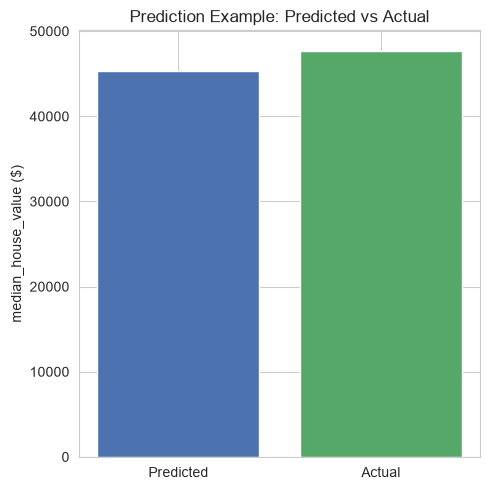

In [26]:
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)
pred_value = best_model.predict(sample_scaled)[0]
actual_value = y_test.iloc[0]

print(f"Model used: {best_model_name}")
print(f"Predicted median_house_value: ${pred_value:,.2f}")
print(f"Actual median_house_value:    ${actual_value:,.2f}")
print(f"Difference: ${abs(pred_value - actual_value):,.2f}")

plt.figure(figsize=(5,5))
plt.bar(["Predicted", "Actual"], [pred_value, actual_value], color=["#4C72B0", "#55A868"])
plt.title("Prediction Example: Predicted vs Actual")
plt.ylabel("median_house_value ($)")
plt.tight_layout()
plt.show()
